In [1]:
!pip install --upgrade langchain langgraph langchain-google-genai langchain-community ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.0/148.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.5/571.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.6.0
    Uninstalling langchain-core-1.6.0:
 

In [2]:
from google.colab import userdata
from langchain.chat_models import init_chat_model

google_api_key = userdata.get('GOOGLE_API_KEY')

llm = init_chat_model("gemini-3.6-flash", model_provider="google_genai", api_key=google_api_key)


# Defining tools

In [3]:
import math
from langchain_core.tools import tool
import numexpr as ne

@tool
def calculator(expression: str) -> str:
    """Useful for evaluating mathematical expressions. Supports basic math, powers, and rounding."""
    try:
        safe_dict = {
            "abs": abs, "round": round, "max": max, "min": min, "sum": sum,
            "sqrt": math.sqrt, "pi": math.pi, "e": math.e,
            "sin": math.sin, "cos": math.cos, "tan": math.tan
        }
        result = eval(expression, {"__builtins__": None}, safe_dict)
        return str(result)
    except Exception as e:
        return f"Error evaluating expression: {str(e)}"


In [4]:
calculator.invoke("2+2")

'4'

In [5]:
print(calculator.name)
print(calculator.description)
print(calculator.args_schema.model_fields)

calculator
Useful for evaluating mathematical expressions. Supports basic math, powers, and rounding.
{'expression': FieldInfo(annotation=str, required=True)}


In [6]:
from pydantic import BaseModel, Field
from typing import Literal

class CalculatorInput(BaseModel):
    """Input for calculator expressions to be computed."""
    expression: str = Field(description="A valid mathematical expression to be evaluated.")


@tool("custom_calculator", description="My calculator", args_schema=CalculatorInput)
def calculator1(expression: str) -> str:
   """Calculates a single mathematical expression, incl. complex numbers.

   Always add * to operations, examples:
     73i -> 73*i
     7pi**2 -> 7*pi**2
   """
   math_constants = {"pi": math.pi, "i": 1j, "e": math.exp}
   result = ne.evaluate(expression.strip(), local_dict=math_constants)
   return str(result)


In [7]:
print(calculator1.name)
print(calculator1.description)
print(calculator1.args_schema.model_fields)

custom_calculator
My calculator
{'expression': FieldInfo(annotation=str, required=True, description='A valid mathematical expression to be evaluated.')}


## ReACT agent

In [8]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()
results = search.invoke("What is the weather like in NYC tomorrow?")

/tmp/ipykernel_520/3112138250.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [9]:
results

"Everything you need to know about tomorrow's weather in New York, NY. High/Low, Precipitation Chances, Sunrise/Sunset, and tomorrow's Temperature History. New York, New York - Detailed weather forecast for tomorrow. Hourly forecast for tomorrow - including weather conditions, temperature, pressure, humidity, precipitation, dewpoint, wind, visibility, and UV index data. New York City NY weather forecast for tomorrow and the next 5 days with detailed summaries of day to night conditions including local barometric pressure, humidity, wind, storms and more! Weather forecast and weather maps for tomorrow at New York, New York, USA. Everything you need to know about tomorrow's weather in Manhattan, NY. High/Low, Precipitation Chances, Sunrise/Sunset, and tomorrow's Temperature History."

In [10]:
print(f"Tool's name = {search.name}")
print(f"Tool's description = {search.description}")


Tool's name = duckduckgo_search
Tool's description = A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.


In [11]:
print(f"Tool's arg schema = f{search.args_schema}")

from langchain_community.tools.ddg_search.tool import DDGInput
print(DDGInput.model_fields)


Tool's arg schema = f<class 'langchain_community.tools.ddg_search.tool.DDGInput'>
{'query': FieldInfo(annotation=str, required=True, description='search query to look up')}


In [12]:
calculator_schema = {
  "name": "calculator",
  "description": "Calculates a single mathematical expression, incl. complex numbers. Always add * to operations, examples: 73i -> 73*i, 7pi**2 -> 7*pi**2",
  "parameters": {
    "type": "object",
    "properties": {
      "expression": {
        "type": "string",
        "description": "The mathematical expression to evaluate."
      }
    },
    "required": [
      "expression"
    ],
  }
}

In [13]:
llm_with_tools = llm.bind_tools([calculator_schema])

prompt = "Can you calculate the value of 7 times pi squared?"
response = llm_with_tools.invoke(prompt)

for tool_call in response.tool_calls:
  print("Model decided to call a tool!")
  print(f"Tool Name: {tool_call['name']}")
  print(f"Arguments: {tool_call['args']}")

Model decided to call a tool!
Tool Name: calculator
Arguments: {'expression': '7*pi**2'}


# ReACT agent

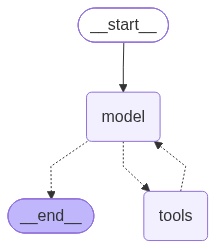

In [14]:

from langchain.agents import create_agent

agent = create_agent(
    llm,
    [search, calculator],
)


from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))


In [15]:
task = "What is the size of Arizone multiplied by pi?"

answer = agent.invoke({"messages": [("user", task)]})

In [16]:
for m in answer["messages"]:
   m.pretty_print()


================================ Human Message =================================

What is the size of Arizone multiplied by pi?
================================== Ai Message ==================================

[]
Tool Calls:
  duckduckgo_search (call_2691882)
 Call ID: call_2691882
  Args:
    query: area of Arizona in square miles square kilometers
================================= Tool Message =================================
Name: duckduckgo_search

Arizona is also one of the Four Corners states and is diagonally adjacent to Colorado. Arizona has a total area of 113,998 square miles (295,253 km2), making it the sixth largest U.S. state. [1] The Prescott metropolitan area includes the cities of Prescott, Cottonwood, Camp Verde and many other towns in the 8,123 square miles (21,000 km2) of Yavapai County area. Arizona has a land area of 113,655.4 square miles and a water area of 329.7 square miles. It is the 6th largest state by area. Arizona is bordered by Utah, Nevada, California, 

In [17]:
print(answer["messages"][-1].text)

Assuming "Arizone" refers to the U.S. state of **Arizona**, here are the calculations based on its total area and land area in both square miles and square kilometers:

---

### 1. Total Area (Land + Water)
* **Square Miles:** $\approx 113,998\text{ sq mi}$
  $$\text{113,998} \times \pi \approx \mathbf{358,135.28}$$

* **Square Kilometers:** $\approx 295,253\text{ km}^2$
  $$\text{295,253} \times \pi \approx \mathbf{927,564.66}$$

---

### 2. Land Area Only
* **Square Miles:** $\approx 113,655.4\text{ sq mi}$
  $$\text{113,655.4} \times \pi \approx \mathbf{357,058.97}$$

* **Square Kilometers:** $\approx 294,366\text{ km}^2$
  $$\text{294,366} \times \pi \approx \mathbf{924,775.31}$$


In [18]:
llm_with_tools = llm.bind_tools([calculator])

In [19]:
result = llm_with_tools.invoke("2*2")
print(result.tool_calls)

[{'name': 'calculator', 'args': {'expression': '2*2'}, 'id': 'call_2031116', 'type': 'tool_call'}]


## ReACT LangGraph agent

In [20]:
from langchain_core.runnables import RunnableConfig
from langgraph.graph import MessagesState

tools = [calculator, search]
llm_with_tools = llm.bind_tools(tools)

def call_model(state: MessagesState, config: RunnableConfig):
    model = config["configurable"].get("llm_with_tools")
    response = model.invoke(state["messages"])

    return {"messages": [response]}

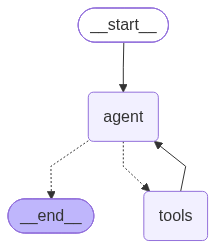

In [21]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

tool_node = ToolNode(tools)

builder = StateGraph(MessagesState)
builder.add_node("agent", call_model)
builder.add_node("tools", tool_node)
builder.add_edge(START, "agent")
builder.add_conditional_edges(
    "agent",
    tools_condition,
)
builder.add_edge("tools", "agent")
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [22]:
answer = graph.invoke(
    {"messages": [("user", task)]},
    config={"configurable": {"llm_with_tools": llm_with_tools}}
)

In [23]:
print(answer["messages"][-1].text)

Assuming "Arizone" refers to the state of **Arizona**, here is the calculation based on its geographic area:

### **Total Area (Land + Water)**
* **In Square Miles:** 
  $$\text{113,998 sq mi} \times \pi \approx \mathbf{358,135.28\text{ sq mi}}$$

* **In Square Kilometers:** 
  $$\text{295,253 km}^2 \times \pi \approx \mathbf{927,564.66\text{ km}^2}$$

---

### **Land Area Only**
* **In Square Miles:** 
  $$\text{113,594 sq mi} \times \pi \approx \mathbf{356,866.08\text{ sq mi}}$$

* **In Square Kilometers:** 
  $$\text{294,207 km}^2 \times \pi \approx \mathbf{924,278.69\text{ km}^2}$$


# Controlled generation

In [24]:
from langchain_core.tools import tool

@tool
def calculate_shipping_cost(destination: str, weight_kg: float) -> str:
    """Calculate the shipping cost for a package to a given destination."""
    cost = round(weight_kg * 5.75, 2)
    return f"Shipping cost to {destination} for a {weight_kg}kg package is ${cost}."


In [25]:
query_general = "What is the capital of France?"
llm_auto = llm.bind_tools([calculate_shipping_cost], tool_choice="auto")
response_auto = llm_auto.invoke(query_general)
print(response_auto.tool_calls)
print(response_auto.text if response_auto.text else "EMPTY RESPONSE")

llm_any = llm.bind_tools([calculate_shipping_cost], tool_choice="any")
response_any = llm_any.invoke(query_general)
print(response_any.tool_calls)
print(response_any.text if response_any.text else "EMPTY RESPONSE")

llm_csc = llm.bind_tools([calculate_shipping_cost], tool_choice="calculate_shipping_cost")
response_csc = llm_csc.invoke(query_general)
print(response_csc.tool_calls)
print(response_csc.text if response_csc.text else "EMPTY RESPONSE")

[]
The capital of France is Paris.
[{'name': 'calculate_shipping_cost', 'args': {'destination': 'Paris', 'weight_kg': 1}, 'id': 'call_2288343', 'type': 'tool_call'}]
EMPTY RESPONSE
[{'name': 'calculate_shipping_cost', 'args': {'destination': 'Paris', 'weight_kg': 1}, 'id': 'call_2056258', 'type': 'tool_call'}]
EMPTY RESPONSE


In [26]:
query_shipping = "You need to send a 500g package from Austin to Los Angeles. How much would it cost?"
llm_auto = llm.bind_tools([calculate_shipping_cost], tool_choice="auto")
response_auto = llm_auto.invoke(query_shipping)
print(response_auto.tool_calls)
print(response_auto.text if response_auto.text else "EMPTY RESPONSE")

llm_any = llm.bind_tools([calculate_shipping_cost], tool_choice="any")
response_any = llm_any.invoke(query_shipping)
print(response_any.tool_calls)
print(response_any.text if response_any.text else "EMPTY RESPONSE")

llm_none = llm.bind_tools([calculate_shipping_cost], tool_choice="none")
response_none = llm_none.invoke(query_shipping)
print(response_none.tool_calls)
print(response_none.text if response_none.text else "EMPTY RESPONSE")

[{'name': 'calculate_shipping_cost', 'args': {'destination': 'Los Angeles', 'weight_kg': 0.5}, 'id': 'call_3701428', 'type': 'tool_call'}]
EMPTY RESPONSE
[{'name': 'calculate_shipping_cost', 'args': {'destination': 'Los Angeles', 'weight_kg': 0.5}, 'id': 'call_1766927', 'type': 'tool_call'}]
EMPTY RESPONSE
[]
The cost to send a **500g (approx. 1.1 lbs)** package from Austin, TX to Los Angeles, CA typically ranges from **$6.50 to $15** for standard ground delivery, depending on the carrier and whether you buy shipping online or at the retail counter.

Because 1.1 lbs is slightly over the 1 lb mark, major US carriers will round the billable weight up to **2 lbs**.

Here is a breakdown of costs across the major carriers (assuming standard box size):

---

### 1. USPS (United States Postal Service) — *Best for Lowest Price*
* **USPS Ground Advantage (2–5 business days):**
  * **Online Rate (e.g., Pirate Ship/Click-N-Ship):** ~$6.50 – $8.50
  * **Retail Counter Rate:** ~$9.50 – $11.00
* **U

Bult-in tools:

In [27]:
llm_with_search = llm.bind_tools([{"google_search": {}}])
response = llm_with_search.invoke("What are the top news stories in tech today?")
print(response.text)

The top news stories in technology feature leadership transitions, major AI policy and security warnings, and announcements ahead of upcoming trade events:

### 1. Leadership Transition at Apple
* **Tim Cook Steps Down as Apple CEO:** August 31, 2026, marks Tim Cook’s final official day as CEO of Apple after 15 years at the helm. Having led Apple's growth from a $350 billion market cap in 2011 to a multi-trillion-dollar giant, Cook is stepping down and handing the reins over to John Ternus.

### 2. AI & Cybersecurity Warnings
* **Bank of England Warns G20 of Systemic AI Risks:** Andrew Bailey, Governor of the Bank of England and Chair of the Financial Stability Board (FSB), sent a letter to G20 finance ministers warning that "frontier" AI models and AI-driven cyberattacks pose growing risks of destabilizing the global financial system.
* **Tech Alliance Calls for "Defensive Surge" Against AI Hacks:** Over 100 major technology companies—including OpenAI, Anthropic, Microsoft, Alphabet, 

In [28]:
grounding_metadata = response.response_metadata.get("grounding_metadata")
print(grounding_metadata.keys())
print(grounding_metadata["web_search_queries"])

dict_keys(['image_search_queries', 'grounding_chunks', 'grounding_supports', 'retrieval_metadata', 'search_entry_point', 'web_search_queries', 'google_maps_widget_context_token', 'retrieval_queries', 'source_flagging_uris'])
['technology news August 31 2026', 'top tech news August 31 2026']


In [29]:
from langchain_core.output_parsers import JsonOutputParser
from pydantic import BaseModel, Field

class CountryFacts(BaseModel):
    name: str = Field(description="The name of the country")
    capital: str = Field(description="The capital city of the country")
    languages: list[str] = Field(description="The official language(s) spoken in the country")
    famous_for: str = Field(description="A brief description of what the country is famous for")

parser = JsonOutputParser(pydantic_object=CountryFacts)

In [30]:
CountryFacts.model_json_schema()

{'properties': {'name': {'description': 'The name of the country',
   'title': 'Name',
   'type': 'string'},
  'capital': {'description': 'The capital city of the country',
   'title': 'Capital',
   'type': 'string'},
  'languages': {'description': 'The official language(s) spoken in the country',
   'items': {'type': 'string'},
   'title': 'Languages',
   'type': 'array'},
  'famous_for': {'description': 'A brief description of what the country is famous for',
   'title': 'Famous For',
   'type': 'string'}},
 'required': ['name', 'capital', 'languages', 'famous_for'],
 'title': 'CountryFacts',
 'type': 'object'}

In [31]:
from langchain_core.prompts import PromptTemplate

template = (
    "You are a helpful geography assistant.\nAnswer the user's query.\n"
    "Return only the JSON value that conforms to the schema:\n{schema}\n\n"
    "Query: {query}\n")

prompt_basic = PromptTemplate(
    template=template,
    input_variables=["query"],
    partial_variables={"schema": CountryFacts.model_json_schema()},
)

chain_basic = prompt_basic | llm | parser

In [32]:
query = "Tell me some facts about Japan."
result = chain_basic.invoke({"query": query})
print(result)

{'name': 'Japan', 'capital': 'Tokyo', 'languages': ['Japanese'], 'famous_for': 'Mount Fuji, sushi, cherry blossoms, advanced technology, anime, and rich cultural traditions.'}


In [33]:
response = (llm | parser).invoke(query, response_schema=CountryFacts.model_json_schema(), response_mime_type="application/json")
print(type(response))
print(response)

<class 'dict'>
{'name': 'Japan', 'capital': 'Tokyo', 'languages': ['Japanese'], 'famous_for': 'Mount Fuji, sushi, anime, high-speed bullet trains, cherry blossoms, and a blend of ancient traditions with modern technology.'}


In [34]:
llm_with_schema = llm.with_structured_output(CountryFacts)
response = llm_with_schema.invoke(query)
print(isinstance(response, CountryFacts))
print(response)

True
name='Japan' capital='Tokyo' languages=['Japanese'] famous_for='Mount Fuji, sushi, cherry blossoms, anime, advanced technology, and rich historical traditions.'


# Plan-and-solve agent

In [35]:
from langchain.agents. middleware import TodoListMiddleware

todo = TodoListMiddleware()
print(todo.system_prompt)

## `write_todos`

You have access to the `write_todos` tool to help you manage and plan complex objectives.
Use this tool for complex objectives to ensure that you are tracking each necessary step.
This tool is very helpful for planning complex objectives, and for breaking down these larger complex objectives into smaller steps.

It is critical that you mark todos as completed as soon as you are done with a step. Do not batch up multiple steps before marking them as completed.
For simple objectives that only require a few steps, it is better to just complete the objective directly and NOT use this tool.
Writing todos takes time and tokens, use it when it is helpful for managing complex many-step problems! But not for simple few-step requests.

## Important To-Do List Usage Notes to Remember

- The `write_todos` tool should never be called multiple times in parallel.
- Don't be afraid to revise the To-Do list as you go. New information may reveal new tasks that need to be done, or old t

In [36]:
todo.tool_description

"Use this tool to create and manage a structured task list for your current work session. This helps you track progress and organize complex tasks.\n\nOnly use this tool if you think it will be helpful in staying organized. If the user's request is trivial and takes less than 3 steps, it is better to NOT use this tool and just do the task directly.\n\n## When to Use This Tool\n\nUse this tool in these scenarios:\n\n1. Complex multi-step tasks - When a task requires 3 or more distinct steps or actions\n2. Non-trivial and complex tasks - Tasks that require careful planning or multiple operations\n3. User explicitly requests todo list - When the user directly asks you to use the todo list\n4. User provides multiple tasks - When users provide a list of things to be done (numbered or comma-separated)\n5. The plan may need future revisions or updates based on results from the first few steps\n\n## How to Use This Tool\n\n1. When you start working on a task - Mark it as in_progress BEFORE beg

In [45]:
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
import sys

@tool
def safe_search(query: str) -> str:
  """Search DuckDuckGo for information about common facts, fresh events and news."""
  try:
    ddg = DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region="us-en"))
    return ddg.invoke(query)
  except Exception as e:
    return f"Search tool encountered a network/DNS error: {str(e)}. Please rely on your internal knowledge or try a different search phrase."


In [46]:
from langchain.agents import create_agent

system_prompt = (
    "You're a smart assistant that carefully helps to solve complex tasks.\n"
    "Don't assume anything, keep in mind things might change and always try to "
    "use tools to double-check yourself.\n"
    "Use a calculator for mathematical computations, and use Search to gather "
    "information about common facts, fresh events, and news."
)

plan_agent = create_agent(
    llm,
    tools=[safe_search, calculator],
    #system_prompt=system_prompt,
    middleware=[TodoListMiddleware()],
)

In [47]:
task = (
    "Identify the current head of government (Prime Minister or President) for each "
    "of the G7 nations. Find their respective birth years, calculate their ages as of today, "
    "and then find the median age of these leaders. Finally, identify which leader's age is "
    "closest to this median, and return their name, country, and age."
)
result = plan_agent.invoke({"messages": [("user", task)]})

In [48]:
from langchain_core.messages import AIMessage, ToolMessage

for m in result["messages"]:
  if isinstance(m, AIMessage):
    for tool in m.tool_calls:
      print(f"calling {tool['name']}")

calling write_todos
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling safe_search
calling write_todos
calling write_todos
calling write_todos


In [49]:
for step in result["todos"]:
  print(step["content"])
  print(step["status"])

Identify current head of government for each G7 nation and their birth years
completed
Calculate the age of each G7 leader as of today
completed
Calculate the median age of these leaders
completed
Identify which leader's age is closest to the median and return their name, country, and age
completed


In [50]:
print(result["messages"][-1].text)

Here is the current head of government for each of the G7 nations, their birth years, current ages, the calculated median age, and the leader whose age is closest to the median.

---

### **G7 Heads of Government & Ages**

1. **Canada**
   * **Head of Government:** Prime Minister Mark Carney
   * **Birth Date & Year:** March 16, 1965
   * **Current Age:** 61 years old

2. **France**
   * **Head of Government:** Prime Minister Sébastien Lecornu *(Head of Government)*  
     *(Note: French President Emmanuel Macron, Head of State, was born Dec 21, 1977, age 48)*
   * **Birth Date & Year:** June 11, 1986
   * **Current Age:** 40 years old

3. **Germany**
   * **Head of Government:** Chancellor Friedrich Merz
   * **Birth Date & Year:** November 11, 1955
   * **Current Age:** 70 years old

4. **Italy**
   * **Head of Government:** Prime Minister Giorgia Meloni
   * **Birth Date & Year:** January 15, 1977
   * **Current Age:** 49 years old

5. **Japan**
   * **Head of Government:** Prime Mi

# Reflection

In [52]:
from datetime import datetime
from langchain_core.tools import tool

@tool
def get_current_date() -> str:
    """Returns the current date. Always use this to get the current date or year rather than searching or guessing."""
    return datetime.now().strftime("%Y-%m-%d")

In [53]:
llm_lite = init_chat_model("gemini-3.1-flash-lite", model_provider="google_genai", api_key=google_api_key)

In [60]:
from langchain.agents import AgentState, create_agent
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage, ToolMessage

_solver_prompt = (
    "You are a specialized task-solving agent that tries to be creative and find new solutions to a problem.\n"
    "Your job is to answer the user's query as accurately as possible using your calculator and search tools.\n"
    "Always use get_current_date if you need to know the current year or date.\n"
    "Perform all necessary steps to get the complete and correct answer.\n"
    "If you receive feedback from the reviewer pointing out inconsistencies or errors, "
    "carefully review the feedback, use your tools again if necessary to verify, and correct your response."
)

task_solver_agent = create_agent(
    llm_lite,
    tools=[calculator, safe_search, get_current_date],
    system_prompt=_solver_prompt,
)

async def task_solver_node(state: AgentState) -> dict[str, list[BaseMessage]]:
    messages = state["messages"]
    if len(messages) > 1:
      messages_to_send = [messages[0]] + messages[-2:]
    else:
        messages_to_send = messages

    new_state = {**state, **{"messages": messages_to_send}}
    res = await task_solver_agent.ainvoke(new_state)
    return {"messages": [res["messages"][-1]]}

In [61]:
a = {"a": 1, "b": 2}
b = {"a": 3}
print({**b, **a})

{'a': 1, 'b': 2}


In [63]:
from pydantic import BaseModel, Field
from typing import Optional
from langchain_core.prompts import ChatPromptTemplate
from langgraph.types import Command
from typing import Literal
from langchain_core.runnables import RunnableConfig

class ReviewerResponse(BaseModel):
    """A structured response model representing the reviewer's verdict."""

    answer: Optional[str] = Field(
        description="The final clean, user-ready synthesis of the answer. It should be empty if a critique has been provided.",
        default=None,
    )
    critique: Optional[str] = Field(
        description="A critique of the initial answer. If you spot any error, inconsistency, missing requirement, or logical gap, provide actionable feedback. It should be empty if the answer is completely correct and approved.",
        default=None,
    )

_reviewer_system_prompt = (
    "You are a critical reviewer agent.\n"
    "Your job is to review the task-solver's proposed answer and verify its correctness and consistency.\n"
    "Carefully check the solver's logic, math calculations, and facts against the tool outputs in the conversation history.\n\n"
    "If you spot ANY error, inconsistency, missing requirement, or logical gap, provide explicit, detailed critique feedback in the critique field.\n"
    "If the proposed answer is completely correct, consistent, and fully addresses the query, provide a clean, final, user-ready synthesis in the answer field."
)


_reviewer_evaluation_template = ChatPromptTemplate.from_messages(
    [
        ("system", _reviewer_system_prompt),
        (
            "human",
            "Please review the task-solver's proposed answer for correctness and consistency.\n\n"
            "Original User Query:\n{original_query}\n\n"
            "Solver's Proposed Answer:\n{proposed_answer}",
        ),
    ]
)

async def reviewer_node(
    state: AgentState,
    config: Optional[RunnableConfig] = None,
) -> Command[Literal["task_solver"]] | dict[str, list[BaseMessage]]:
    """Run the reviewer agent and update reflection steps."""
    configurable = config.get("configurable", {}) if config else {}
    reflection_depth = configurable.get("reflection_depth", 3)
    feedback_steps = sum(
        1
        for msg in state["messages"]
        if isinstance(msg, HumanMessage) and getattr(msg, "name", None) == "reviewer"
    )
    if feedback_steps >= reflection_depth:
        print(
            "\n⚠️ [Max Reflection Steps Reached] Routing to END to avoid infinite loop."
        )
        return {}

    original_query = state["messages"][0].text
    proposed_answer = state["messages"][-1].text

    reviewer_llm = llm.with_structured_output(ReviewerResponse)
    res = await (_reviewer_evaluation_template | reviewer_llm).ainvoke(
        {"original_query": original_query, "proposed_answer": proposed_answer})

    if res.critique:
        feedback_msg = HumanMessage(
            content=f"FEEDBACK: {res.critique}", name="reviewer"
        )
        print(
            f"\n🔄 [Reviewer found inconsistencies] Routing back to Task Solver (Step {feedback_steps + 1}/{reflection_depth})."
        )
        return Command(
            goto="task_solver",
            update={"messages": [feedback_msg]}
        )

    approved_content = res.answer or proposed_answer
    print("\n✅ [Approved] Routing to END.")
    return {"messages": [AIMessage(content=approved_content)]}

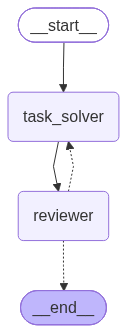

In [64]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(AgentState)
builder.add_node("task_solver", task_solver_node)
builder.add_node("reviewer", reviewer_node)

builder.add_edge(START, "task_solver")
builder.add_edge("task_solver", "reviewer")
builder.add_edge("reviewer", END)

reflection = builder.compile()
from IPython.display import Image, display
display(Image(reflection.get_graph().draw_mermaid_png()))

In [65]:
task = (
    "Identify the current head of government (Prime Minister or President) for each "
    "of the G7 nations. Find their respective birth years, calculate their ages as of today, "
    "and then find the median age of these leaders. Finally, identify which leader's age is "
    "closest to this median, and return their name, country, and age.",
)

In [66]:
result = await reflection.ainvoke({"messages": [("user", task)]})


🔄 [Reviewer found inconsistencies] Routing back to Task Solver (Step 1/3).

🔄 [Reviewer found inconsistencies] Routing back to Task Solver (Step 2/3).

🔄 [Reviewer found inconsistencies] Routing back to Task Solver (Step 3/3).



⚠️ [Max Reflection Steps Reached] Routing to END to avoid infinite loop.


In [67]:
print(result["messages"][-1].text)

To identify the current heads of government for the G7 nations as of today, August 31, 2026, I have retrieved the following information:

| Country | Head of Government | Birth Year | Age (as of Aug 31, 2026) |
| :--- | :--- | :--- | :--- |
| Canada | Mark Carney | 1965 | 61 |
| France | Sébastien Lecornu | 1986 | 40 |
| Germany | Friedrich Merz | 1955 | 71 |
| Italy | Giorgia Meloni | 1977 | 49 |
| Japan | Sanae Takaichi | 1961 | 65 |
| United Kingdom | Andy Burnham | 1970 | 56 |
| United States | Donald Trump | 1946 | 80 |

### Median Age Calculation
To determine the median age, we arrange the ages in ascending order:
40, 49, 56, **61**, 65, 71, 80

The median age is **61**.

### Leader Closest to the Median Age
Comparing the age of each leader to the median age of 61:
*   Mark Carney: |61 - 61| = 0
*   Sanae Takaichi: |65 - 61| = 4
*   Andy Burnham: |56 - 61| = 5
*   Friedrich Merz: |71 - 61| = 10
*   Giorgia Meloni: |49 - 61| = 12
*   Donald Trump: |80 - 61| = 19
*   Sébastien Leco